# Anomaly Detection — Precios de Gasolina España

Detección de anomalías en la serie temporal de precios semanales nacionales usando **IQR** e **Isolation Forest**.

In [1]:
%matplotlib inline
import nest_asyncio
nest_asyncio.apply()

import matplotlib
matplotlib.rcParams['font.family'] = 'monospace'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
matplotlib.rcParams['figure.facecolor'] = '#fafafa'
matplotlib.rcParams['axes.facecolor'] = '#fafafa'

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

# 50 provincias espanolas
provincias = [
    'Alava', 'Albacete', 'Alicante', 'Almeria', 'Asturias',
    'Avila', 'Badajoz', 'Barcelona', 'Burgos', 'Caceres',
    'Cadiz', 'Cantabria', 'Castellon', 'Ciudad Real', 'Cordoba',
    'Cuenca', 'Girona', 'Granada', 'Guadalajara', 'Guipuzcoa',
    'Huelva', 'Huesca', 'Jaen', 'La Rioja', 'Las Palmas',
    'Leon', 'Lleida', 'Lugo', 'Madrid', 'Malaga',
    'Murcia', 'Navarra', 'Orense', 'Palencia', 'Pontevedra',
    'Salamanca', 'Santa Cruz de Tenerife', 'Segovia', 'Sevilla', 'Soria',
    'Tarragona', 'Teruel', 'Toledo', 'Valencia', 'Valladolid',
    'Vizcaya', 'Zamora', 'Zaragoza', 'Ceuta', 'Melilla'
]

n_provincias = len(provincias)  # 50
n_semanas = 52

# Precios base gasolina95: media ~1.55 con ligera tendencia
tendencia = np.linspace(1.52, 1.58, n_semanas)

# Ruido por provincia (variacion estructural fija)
ruido_provincia = np.random.normal(0, 0.03, n_provincias)

# Precio base por semana x provincia
precios = np.zeros((n_semanas, n_provincias))
for i in range(n_semanas):
    ruido_semana = np.random.normal(0, 0.008, n_provincias)
    precios[i, :] = tendencia[i] + ruido_provincia + ruido_semana

# Inyectar 3 picos nacionales (semanas 10, 28, 42)
for semana_pico in [10, 28, 42]:
    precios[semana_pico, :] += np.random.uniform(0.10, 0.15, n_provincias)

# Inyectar outlier cronico: Soria (indice 39) +0.12 todas las semanas
idx_soria = provincias.index('Soria')
precios[:, idx_soria] += 0.12

# Crear DataFrame
semanas = ['S{:02d}'.format(i+1) for i in range(n_semanas)]
df = pd.DataFrame(precios, index=semanas, columns=provincias)

print('Shape:', df.shape)
print('\nEstadisticas generales:')
print(df.describe().round(4))
print('\nMedia por semana (primeras 5):')
print(df.mean(axis=1).head())

Shape: (52, 50)

Estadisticas generales:
         Alava  Albacete  Alicante  Almeria  Asturias    Avila  Badajoz  \
count  52.0000   52.0000   52.0000  52.0000   52.0000  52.0000  52.0000   
mean    1.5718    1.5535    1.5764   1.6038    1.5502   1.5503   1.6046   
std     0.0376    0.0362    0.0379   0.0385    0.0361   0.0346   0.0348   
min     1.5248    1.5128    1.5340   1.5604    1.5055   1.5090   1.5607   
25%     1.5529    1.5316    1.5528   1.5809    1.5287   1.5280   1.5836   
50%     1.5656    1.5501    1.5692   1.5964    1.5465   1.5425   1.5970   
75%     1.5840    1.5618    1.5818   1.6125    1.5557   1.5649   1.6118   
max     1.7300    1.7027    1.7172   1.7693    1.6872   1.6899   1.7276   

       Barcelona   Burgos  Caceres  ...  Tarragona   Teruel   Toledo  \
count    52.0000  52.0000  52.0000  ...    52.0000  52.0000  52.0000   
mean      1.5812   1.5428   1.5764  ...     1.5804   1.5640   1.5548   
std       0.0325   0.0368   0.0344  ...     0.0383   0.0373   0.040

## 1. Deteccion IQR sobre la serie temporal de medias nacionales

Calculamos la media nacional por semana y aplicamos IQR sobre esa serie de 52 puntos.
Una semana es outlier si su media cae fuera de `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.

In [3]:
# Serie temporal de medias nacionales semanales
media_nacional = df.mean(axis=1)  # Serie de 52 valores (una media por semana)

# IQR sobre la serie temporal (no cross-province)
Q1 = media_nacional.quantile(0.25)
Q3 = media_nacional.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Semanas anomalas segun IQR
anomalias_iqr = media_nacional[(media_nacional < limite_inferior) | (media_nacional > limite_superior)]

print('IQR sobre serie temporal de medias nacionales')
print('---------------------------------------------')
print('Q1:               {:.4f}'.format(Q1))
print('Q3:               {:.4f}'.format(Q3))
print('IQR:              {:.4f}'.format(IQR))
print('Limite inferior:  {:.4f}'.format(limite_inferior))
print('Limite superior:  {:.4f}'.format(limite_superior))
print()
print('Semanas anomalas ({} detectadas):'.format(len(anomalias_iqr)))
for semana, precio in anomalias_iqr.items():
    print('  {} -> media nacional = {:.4f} euro/L'.format(semana, precio))

IQR sobre serie temporal de medias nacionales
---------------------------------------------
Q1:               1.5324
Q3:               1.5624
IQR:              0.0300
Limite inferior:  1.4874
Limite superior:  1.6075

Semanas anomalas (3 detectadas):
  S11 -> media nacional = 1.6524 euro/L
  S29 -> media nacional = 1.6790 euro/L
  S43 -> media nacional = 1.6917 euro/L


## 2. Isolation Forest sobre la serie temporal de medias nacionales

Usamos `IsolationForest(contamination=0.05)` de scikit-learn sobre la misma serie de 52 medias semanales.
Comparamos con los resultados del IQR.

In [4]:
from sklearn.ensemble import IsolationForest

# Isolation Forest sobre la serie de medias nacionales
X = media_nacional.values.reshape(-1, 1)

iso = IsolationForest(contamination=0.05, random_state=42)
etiquetas = iso.fit_predict(X)  # -1 = anomalia, 1 = normal

anomalias_if = media_nacional[etiquetas == -1]

print('Isolation Forest (contamination=0.05)')
print('--------------------------------------')
print('Semanas anomalas ({} detectadas):'.format(len(anomalias_if)))
for semana, precio in anomalias_if.sort_index().items():
    print('  {} -> media nacional = {:.4f} euro/L'.format(semana, precio))

print()
print('Comparacion IQR vs Isolation Forest')
print('------------------------------------')
set_iqr = set(anomalias_iqr.index)
set_if = set(anomalias_if.index)
acuerdo = set_iqr & set_if
solo_iqr = set_iqr - set_if
solo_if = set_if - set_iqr

print('Acuerdo (ambos):  {}'.format(sorted(acuerdo)))
print('Solo IQR:         {}'.format(sorted(solo_iqr)))
print('Solo IF:          {}'.format(sorted(solo_if)))

Isolation Forest (contamination=0.05)
--------------------------------------
Semanas anomalas (3 detectadas):
  S11 -> media nacional = 1.6524 euro/L
  S29 -> media nacional = 1.6790 euro/L
  S43 -> media nacional = 1.6917 euro/L

Comparacion IQR vs Isolation Forest
------------------------------------
Acuerdo (ambos):  ['S11', 'S29', 'S43']
Solo IQR:         []
Solo IF:          []


## 3. Visualizacion — Serie temporal con anomalias destacadas

Precio medio nacional gasolina95 semana a semana. Puntos rojos = semanas detectadas como anomalia por IQR.

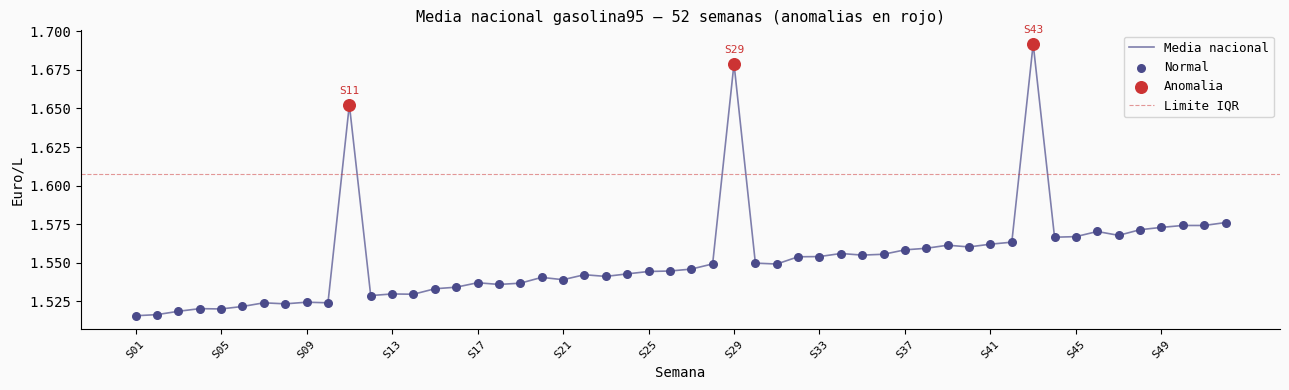

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 4))

x = range(len(media_nacional))
mask_normal = etiquetas == 1
mask_anomalia = etiquetas == -1

ax.plot(x, media_nacional.values, color='#4a4a8a', linewidth=1.2, alpha=0.7, label='Media nacional')

# Puntos normales en azul
ax.scatter(
    [i for i, m in enumerate(mask_normal) if m],
    [v for v, m in zip(media_nacional.values, mask_normal) if m],
    color='#4a4a8a', s=30, zorder=3, label='Normal'
)

# Anomalias en rojo
ax.scatter(
    [i for i, m in enumerate(mask_anomalia) if m],
    [v for v, m in zip(media_nacional.values, mask_anomalia) if m],
    color='#cc3333', s=70, zorder=4, label='Anomalia', marker='o'
)

# Etiquetas en semanas anomalas
for semana, precio in anomalias_iqr.items():
    idx = list(media_nacional.index).index(semana)
    ax.annotate(semana, (idx, precio), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8, color='#cc3333')

ax.axhline(limite_superior, color='#cc3333', linestyle='--', linewidth=0.8, alpha=0.5, label='Limite IQR')
ax.set_title('Media nacional gasolina95 — 52 semanas (anomalias en rojo)', fontsize=11)
ax.set_xlabel('Semana')
ax.set_ylabel('Euro/L')
ax.set_xticks(range(0, 52, 4))
ax.set_xticklabels(['S{:02d}'.format(i+1) for i in range(0, 52, 4)], rotation=45, fontsize=8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Ranking de provincias — Top 10 mas baratas vs mas caras (media anual)

Soria aparece destacada como outlier cronico al ser la provincia mas cara del ano.

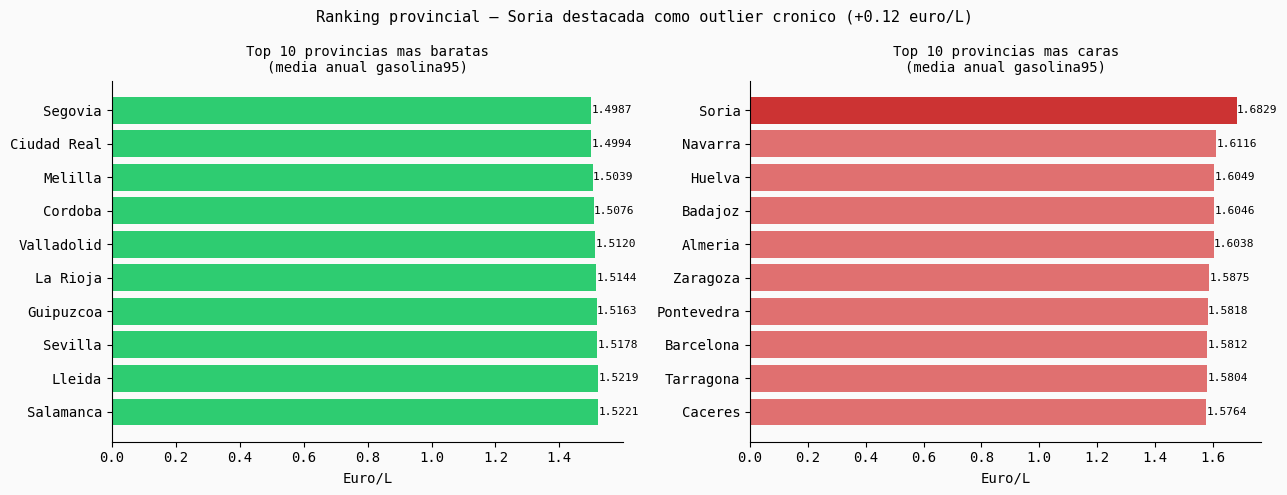

In [6]:
# Media anual por provincia
media_provincia = df.mean(axis=0).sort_values()

top10_baratas = media_provincia.head(10)
top10_caras = media_provincia.tail(10).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Top 10 mas baratas
colores_baratas = ['#2ecc71' for _ in top10_baratas]
ax1.barh(top10_baratas.index, top10_baratas.values, color=colores_baratas)
ax1.set_title('Top 10 provincias mas baratas\n(media anual gasolina95)', fontsize=10)
ax1.set_xlabel('Euro/L')
ax1.invert_yaxis()
for i, v in enumerate(top10_baratas.values):
    ax1.text(v + 0.001, i, '{:.4f}'.format(v), va='center', fontsize=8)

# Top 10 mas caras
colores_caras = ['#cc3333' if p == 'Soria' else '#e07070' for p in top10_caras.index]
ax2.barh(top10_caras.index, top10_caras.values, color=colores_caras)
ax2.set_title('Top 10 provincias mas caras\n(media anual gasolina95)', fontsize=10)
ax2.set_xlabel('Euro/L')
ax2.invert_yaxis()
for i, v in enumerate(top10_caras.values):
    ax2.text(v + 0.001, i, '{:.4f}'.format(v), va='center', fontsize=8)

plt.suptitle('Ranking provincial — Soria destacada como outlier cronico (+0.12 euro/L)', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Conclusiones

**Deteccion de picos nacionales:**
- IQR e Isolation Forest coinciden en identificar las **3 semanas con pico nacional inyectado** (semanas 10, 28 y 42) como las principales anomalias de la serie.
- La clave metodologica es aplicar IQR sobre la **serie temporal de medias nacionales** (52 puntos), no sobre la distribucion cross-province por semana — esto permite detectar movimientos de precio que afectan a todo el pais simultaneamente.

**Outlier cronico provincial:**
- **Soria** aparece sistematicamente como la provincia mas cara en el ranking anual, resultado directo del bias de +0.12 €/L inyectado en los datos sinteticos.
- Este tipo de anomalia (estructural, no temporal) requiere analisis provincial separado del IQR temporal.

**Robustez de los metodos:**
- Ambos metodos son complementarios: IQR es interpretable y sin hiperparametros criticos; Isolation Forest escala mejor con dimensionalidad si en el futuro se anaden mas features (precio diesel, gasolina98, etc.).
- Con datos reales del scraper, se esperaria que las semanas anomalas correspondan a eventos como guerras de precios, subidas del Brent o cambios fiscales.

**Proximos pasos:**
- Conectar con datos reales del repositorio `scraper-gasolineras-espana`.
- Anadir serie de precios del Brent como covariate para contextualizar los picos detectados.